<div style="width: 100%; clear: both;">
  <div style="float: left; width: 50%;">
    <img src="https://www.ucc.edu.co/institucional/acerca-de-la-universidad/Documents/logo_ucc_2018(CURVAS)-01.png" align="left" style="max-width: 100%; height: auto;">
  </div>
  <div style="float: right; width: 50%;">
    <p style="margin: 0; padding-top: 22px; text-align:right;"><strong>Laboratorio de Tecnologias Emergentes</strong></p>
    <p style="margin: 0; text-align:right;"><strong>Linea de Inteligencia Artificial</strong></p>
    <p style="margin: 0; text-align:right;">Universidad Cooperativa de Colombia, Campus Ibague-Espinal</p>
    <p style="margin: 0; text-align:right;">Facultad de Ingenieria</p>
    <p style="margin: 0; text-align:right; padding-bottom: 100px;">Programa de Ingenieria de Sistemas</p>
  </div>
</div>
<div style="width:100%;">&nbsp;</div>
<div style="font-size: 20px; font-weight: bold; background: linear-gradient(to right, #ff7e5f, #feb47b); -webkit-background-clip: text; color: grey; text-align: center">W&F BirdLab — 01 Data Ingestion</div>

# 01 — Data Ingestion

Este notebook cubre el primer paso del pipeline: **cargar el dataset crudo**.

`src/data/ingestion.py` se encarga de:
1. Leer el `.zip` con las imagenes de aves
2. Extraer cada carpeta de clase en `data/raw/`
3. Reportar cuantas imagenes encontro por especie

La configuracion (rutas, tamanio de imagen, splits) se lee desde `configs/dataset.yaml`.

```
dataset.zip
├── ESPECIE_A/  →  data/raw/ESPECIE_A/
├── ESPECIE_B/  →  data/raw/ESPECIE_B/
└── ...
```


## 1. Verificar configuracion

In [2]:
import sys
from pathlib import Path
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Asegurar que src/ esta en el path para importar ingestion
PROJECT_ROOT = Path.cwd().parent   
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "dataset.yaml"

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

print("Configuracion cargada desde:", CONFIG_PATH)
print()
for k, v in config.items():
    print(f"  {k:<25} {v}")


/home/walter/miniconda3/envs/aves/lib/python3.10/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


Configuracion cargada desde: /home/walter/projects/aves/configs/dataset.yaml

  raw_data_path             data/raw
  processed_data_path       data/processed
  split_ratio               [0.75, 0.15, 0.1]
  image_size                224


## 2. Ejecutar la ingestion

Ajusta `ZIP_PATH` a la ruta de tu archivo `.zip`.  
El resto lo resuelve `ingest_zip()` automaticamente.


In [3]:
from src.data.ingestion import ingest_zip

# ── Ruta al archivo zip ─────────────────────────────────────────
ZIP_PATH = PROJECT_ROOT / "data" / "raw" / "dataset.zip"

result = ingest_zip(
    zip_path=str(ZIP_PATH),
    config_path=str(CONFIG_PATH),
    verbose=True,        # imprime el reporte en consola
)


────────────────────────────────────────────────────
  INGESTION REPORT — W&F BirdLab
────────────────────────────────────────────────────
  Origen  : /home/walter/projects/aves/data/raw/dataset.zip
  Destino : data/raw
  Clases encontradas: 16

  Clase                               Imagenes
  ----------------------------------- --------
  ardea-alba                               511
  atlapetes-latinuchus                     781
  butorides-striata                        532
  chlorochrysa-nitidissima                 639
  colibri-coruscans                        589
  common-gallinule                         640
  metallura-tyrianthina                    645
  momotus-aequatorialis                    926
  phimosus-infuscatus                      626
  piaya-cayana                             784
  pitangus-sulphuratus                     481
  ramphastos-ambiguus                      957
  sicalis-flaveola                         578
  thraupis-episcopus                       500
  

## 3. Resultados basicos

In [4]:
classes      = result["classes"]
counts       = result["counts"]
total_images = result["total_images"]
raw_dir      = result["raw_dir"]
skipped      = result["skipped_files"]

print(f"Clases encontradas : {len(classes)}")
print(f"Total de imagenes  : {total_images}")
print(f"Archivos ignorados : {len(skipped)}")
print(f"Directorio raw     : {raw_dir.resolve()}")


Clases encontradas : 16
Total de imagenes  : 10245
Archivos ignorados : 38
Directorio raw     : /home/walter/projects/aves/notebooks/data/raw


## 4. Distribucion de imagenes por clase

Una distribucion muy desigual (clases con pocas imagenes vs. clases con muchas)
puede causar que el modelo aprenda mejor unas especies que otras.
Esto es lo primero que debemos revisar antes de entrenar.


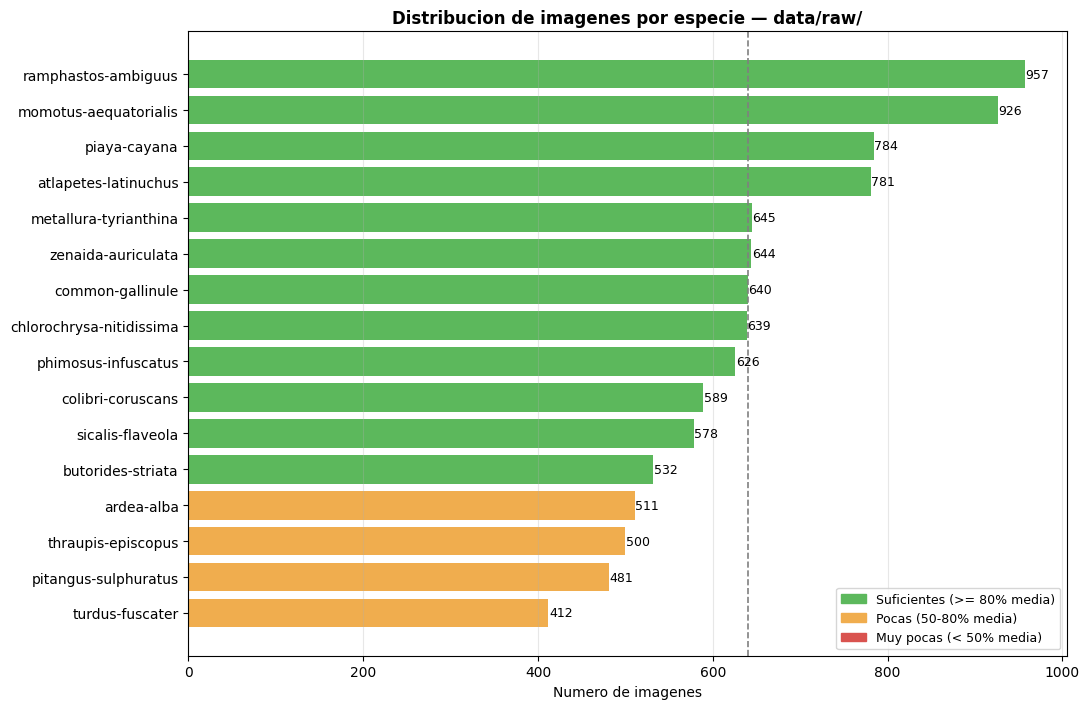

Grafica guardada en logs/01_distribucion_raw.png


In [6]:
sorted_items = sorted(counts.items(), key=lambda x: x[1], reverse=True)
sorted_cls   = [k for k, _ in sorted_items]
sorted_cnt   = [v for _, v in sorted_items]

mean_count = np.mean(sorted_cnt)
colors = [
    "#d9534f" if v < mean_count * 0.5 else
    "#f0ad4e" if v < mean_count * 0.8 else
    "#5cb85c"
    for v in sorted_cnt
]

fig, ax = plt.subplots(figsize=(11, max(5, len(classes) * 0.45)))
bars = ax.barh(sorted_cls[::-1], sorted_cnt[::-1], color=colors[::-1])
ax.axvline(x=mean_count, color="gray", linestyle="--", linewidth=1.2,
           label=f"Media: {mean_count:.0f} imgs")

for bar, val in zip(bars, sorted_cnt[::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=9)

patches = [
    mpatches.Patch(color="#5cb85c", label="Suficientes (>= 80% media)"),
    mpatches.Patch(color="#f0ad4e", label="Pocas (50-80% media)"),
    mpatches.Patch(color="#d9534f", label="Muy pocas (< 50% media)"),
]
ax.legend(handles=patches, loc="lower right", fontsize=9)
ax.set_xlabel("Numero de imagenes")
ax.set_title("Distribucion de imagenes por especie — data/raw/", fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "logs" / "01_distribucion_raw.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Grafica guardada en logs/01_distribucion_raw.png")


## 5. Tabla resumen y alertas

In [7]:
mean_count = np.mean(list(counts.values()))

print(f"{'Clase':<35} {'Imagenes':>9}  {'Estado'}")
print("-" * 62)
for cls in sorted_cls:
    n = counts[cls]
    if   n < mean_count * 0.5:  estado = "[!] Muy pocas imagenes"
    elif n < mean_count * 0.8:  estado = "[~] Pocas imagenes"
    else:                        estado = "[OK]"
    print(f"{cls:<35} {n:>9}  {estado}")

print("-" * 62)
print(f"{'TOTAL':<35} {total_images:>9}")
print(f"{'Media por clase':<35} {mean_count:>9.1f}")
print()

clases_bajas = [c for c in classes if counts[c] < mean_count * 0.5]
if clases_bajas:
    print("Clases con muy pocas imagenes (< 50% de la media):")
    for c in clases_bajas:
        print(f"  - {c}: {counts[c]} imagenes")
    print()
    print("Recomendacion: recolectar mas imagenes de estas clases antes")
    print("de pasar a la etapa de preprocesamiento.")
else:
    print("Distribucion balanceada. Puedes continuar con el preprocesamiento.")


Clase                                Imagenes  Estado
--------------------------------------------------------------
ramphastos-ambiguus                       957  [OK]
momotus-aequatorialis                     926  [OK]
piaya-cayana                              784  [OK]
atlapetes-latinuchus                      781  [OK]
metallura-tyrianthina                     645  [OK]
zenaida-auriculata                        644  [OK]
common-gallinule                          640  [OK]
chlorochrysa-nitidissima                  639  [OK]
phimosus-infuscatus                       626  [OK]
colibri-coruscans                         589  [OK]
sicalis-flaveola                          578  [OK]
butorides-striata                         532  [OK]
ardea-alba                                511  [~] Pocas imagenes
thraupis-episcopus                        500  [~] Pocas imagenes
pitangus-sulphuratus                      481  [~] Pocas imagenes
turdus-fuscater                           412  [~] Pocas imag

## 6. Verificacion de la estructura en disco

In [8]:
print("Estructura generada en data/raw/:")
print()
raw_dir = PROJECT_ROOT / result["raw_dir"]
for cls_dir in sorted(raw_dir.iterdir()):
    if cls_dir.is_dir():
        imgs = [f for f in cls_dir.iterdir()
                if f.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}]
        print(f"  data/raw/{cls_dir.name}/  ({len(imgs)} imagenes)")
print()
print("Siguiente paso -> notebooks/02_preprocessing.ipynb")


Estructura generada en data/raw/:

  data/raw/ardea-alba/  (251 imagenes)
  data/raw/atlapetes-latinuchus/  (277 imagenes)
  data/raw/butorides-striata/  (266 imagenes)
  data/raw/chlorochrysa-nitidissima/  (303 imagenes)
  data/raw/colibri-coruscans/  (291 imagenes)
  data/raw/common-gallinule/  (307 imagenes)
  data/raw/metallura-tyrianthina/  (291 imagenes)
  data/raw/momotus-aequatorialis/  (463 imagenes)
  data/raw/phimosus-infuscatus/  (313 imagenes)
  data/raw/piaya-cayana/  (346 imagenes)
  data/raw/pitangus-sulphuratus/  (240 imagenes)
  data/raw/ramphastos-ambiguus/  (329 imagenes)
  data/raw/sicalis-flaveola/  (289 imagenes)
  data/raw/thraupis-episcopus/  (250 imagenes)
  data/raw/turdus-fuscater/  (206 imagenes)
  data/raw/zenaida-auriculata/  (273 imagenes)

Siguiente paso -> notebooks/02_preprocessing.ipynb
